# Task 4: Visualization Critique + Redesign

This notebook critiques two real-world charts from the public article *Misleading Graphs: Real Life Examples* and then recreates them with clearer design choices.

Source page: https://www.statisticshowto.com/probability-and-statistics/descriptive-statistics/misleading-graphs/

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

base_folder = r"c:\Users\PM\Desktop\Internship\AI-Data-Engineering-Internship\Week-6 May_26"
output_folder = os.path.join(base_folder, "Task4")
os.makedirs(output_folder, exist_ok=True)

output_folder

'c:\\Users\\PM\\Desktop\\Internship\\AI-Data-Engineering-Internship\\Week-6 May_26\\Task4'

## Chart 1 Source: Terry Schiavo approval chart

![Original Terry Schiavo chart](https://www.statisticshowto.com/wp-content/uploads/2014/01/terry-schiavo-misleading-graph.jpg)

Source: https://www.statisticshowto.com/probability-and-statistics/descriptive-statistics/misleading-graphs/

### Three design flaws
1. The vertical axis is truncated, which makes the gap between 62% and 54% look much larger than it really is.
2. The bars and scale encourage a dramatic visual comparison instead of a proportional one.
3. The chart lacks enough context for a quick reader, so the visual emphasis is stronger than the actual difference in the data.

### Before/after plan
Before: the chart exaggerates the difference through scale manipulation.
After: a zero-based bar chart with direct labels and a cleaner title makes the comparison honest.

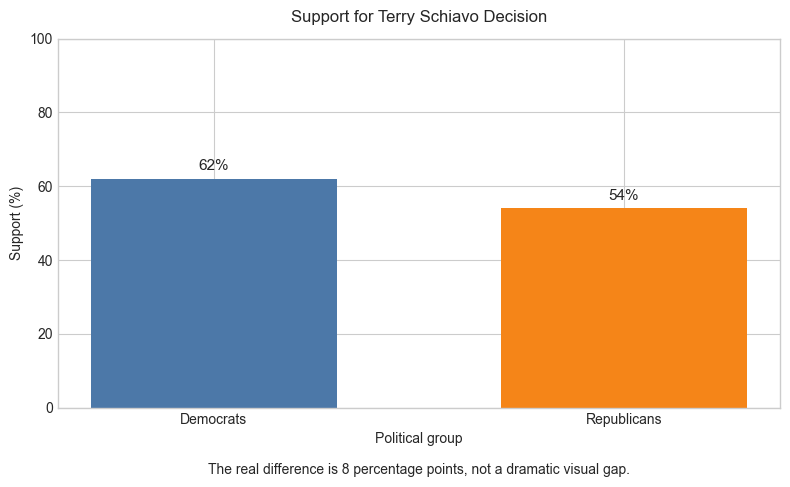

'c:\\Users\\PM\\Desktop\\Internship\\AI-Data-Engineering-Internship\\Week-6 May_26\\Task4\\task4_chart1_redesign.png'

In [10]:
# Recreate the chart with an honest zero-based scale and clearer labeling.
chart1_df = pd.DataFrame({
    "Group": ["Democrats", "Republicans"],
    "Support": [62, 54],
})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(chart1_df["Group"], chart1_df["Support"], color=["#4C78A8", "#F58518"], width=0.6)

ax.set_title("Support for Terry Schiavo Decision", pad=12)
ax.set_xlabel("Political group")
ax.set_ylabel("Support (%)")
ax.set_ylim(0, 100)

for bar, value in zip(bars, chart1_df["Support"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value}%", ha="center", va="bottom", fontsize=11)

ax.text(0.5, -0.18, "The real difference is 8 percentage points, not a dramatic visual gap.", ha="center", transform=ax.transAxes)
plt.tight_layout()
chart1_output = os.path.join(output_folder, "task4_chart1_redesign.png")
plt.savefig(chart1_output, dpi=300, bbox_inches="tight")
plt.show()

chart1_output

### Before/after comparison for Chart 1

The original chart uses a truncated y-axis, so the bars imply a much larger difference than the data actually supports. The redesign fixes that by starting the axis at zero, labeling the bars directly, and using a restrained color palette. The result is still easy to read, but the comparison is now proportional instead of exaggerated.

## Chart 2 Source: Fox News unemployment chart

![Original Fox News unemployment chart](https://www.statisticshowto.com/wp-content/uploads/2014/01/unemployment-rate.jpg)

Source: https://www.statisticshowto.com/probability-and-statistics/descriptive-statistics/misleading-graphs/

### Three design flaws
1. The chart makes a small change in unemployment look like a steep upward trend by manipulating the y-axis framing.
2. One of the plotted values is placed incorrectly, so the visual position does not match the actual number.
3. The chart encourages an exponential-growth interpretation even though the article says the overall trend is fairly stable around 9%.

### Before/after plan
Before: the chart implies a dramatic rise that the data does not support.
After: a clean line chart with accurate point placement and a readable scale shows the near-flat trend more honestly.

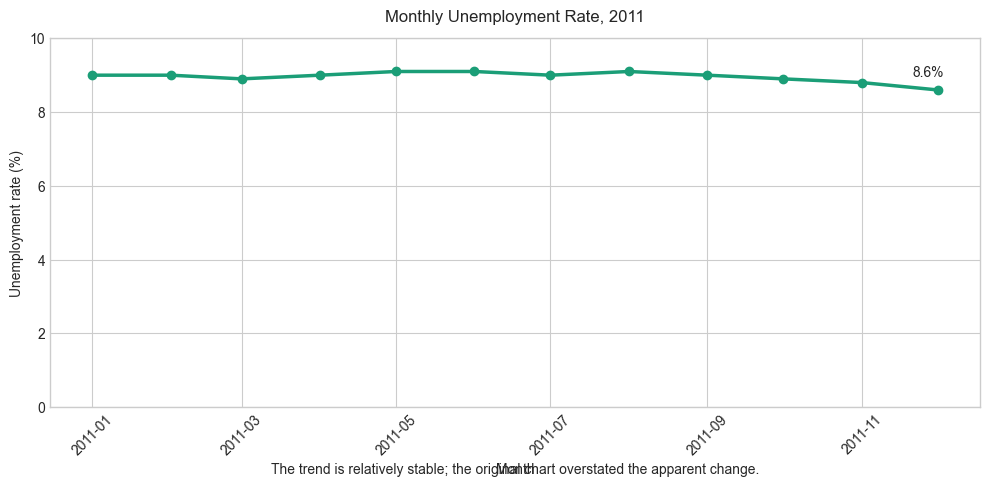

'c:\\Users\\PM\\Desktop\\Internship\\AI-Data-Engineering-Internship\\Week-6 May_26\\Task4\\task4_chart2_redesign.png'

In [11]:
# Recreate the trend with a transparent time series and clear annotations.
months = pd.date_range("2011-01-01", periods=12, freq="MS")
unemployment_rate = [9.0, 9.0, 8.9, 9.0, 9.1, 9.1, 9.0, 9.1, 9.0, 8.9, 8.8, 8.6]
trend_df = pd.DataFrame({
    "Month": months,
    "UnemploymentRate": unemployment_rate,
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend_df["Month"], trend_df["UnemploymentRate"], marker="o", color="#1B9E77", linewidth=2.5)

ax.set_title("Monthly Unemployment Rate, 2011", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Unemployment rate (%)")
ax.set_ylim(0, 10)
ax.tick_params(axis="x", rotation=45)

ax.annotate("8.6%", xy=(trend_df.iloc[-1]["Month"], trend_df.iloc[-1]["UnemploymentRate"]), xytext=(-18, 10), textcoords="offset points")
ax.text(0.5, -0.18, "The trend is relatively stable; the original chart overstated the apparent change.", ha="center", transform=ax.transAxes)
plt.tight_layout()
chart2_output = os.path.join(output_folder, "task4_chart2_redesign.png")
plt.savefig(chart2_output, dpi=300, bbox_inches="tight")
plt.show()

chart2_output

### Before/after comparison for Chart 2

The original chart is misleading because the scale makes a small fluctuation look like a dramatic pattern, and the plotted point positions are not trustworthy. The redesign uses a plain line chart, consistent monthly spacing, and a readable y-axis so the size of the change is clear. It also keeps the emphasis on the data itself instead of the visual drama.

In [12]:
sorted([name for name in os.listdir(output_folder) if name.endswith(".png")])

['task4_chart1_redesign.png', 'task4_chart2_redesign.png']